In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

C:\Users\Sayali\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
C:\Users\Sayali\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps, copy_X=True, fit_path=T

In [12]:
df = pd.read_csv(r"C:\Users\Sayali\Desktop\academics\dsbda_practs\DSBDA Lab Datasets\DSBDA Lab Datasets\AirQualityUCI.csv", encoding='utf-8-sig')

In [13]:
df.shape

(9471, 17)

In [14]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10-03-2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10-03-2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10-03-2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10-03-2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10-03-2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [15]:
# Data Cleaning

# Drop unnamed or empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [16]:
df.shape

(9471, 15)

In [17]:
# Replace missing values denoted by -200 with NaN
df.replace(-200, np.nan, inplace=True)
print("Missing values before cleaning:")
df.isna().sum()

Missing values before cleaning:


Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

In [18]:
# Drop rows where target variable is missing
df.dropna(subset=['CO(GT)'], inplace=True)

In [19]:
# Fill other missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print("\nMissing values after cleaning:")
df.isna().sum()


Missing values after cleaning:


Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [20]:
# Convert 'Date' and 'Time' to datetime
print("\n3. Feature Engineering:")
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)


3. Feature Engineering:


In [21]:
df.shape

(7674, 14)

In [22]:
# Data Integration
df.set_index('Datetime', inplace=True)
print("Dataframe with datetime index:")
df.head()

Dataframe with datetime index:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [23]:
# Data Transformation
print("\n5. Data Transformation (Normalization):")
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("Normalized data summary:")
print(df.describe().transpose()[['min', 'max', 'mean']])


5. Data Transformation (Normalization):
Normalized data summary:
               min  max      mean
CO(GT)         0.0  1.0  0.173962
PT08.S1(CO)    0.0  1.0  0.332793
NMHC(GT)       0.0  1.0  0.183284
C6H6(GT)       0.0  1.0  0.158673
PT08.S2(NMHC)  0.0  1.0  0.306622
NOx(GT)        0.0  1.0  0.171506
PT08.S3(NOx)   0.0  1.0  0.213859
NO2(GT)        0.0  1.0  0.333763
PT08.S4(NO2)   0.0  1.0  0.401867
PT08.S5(O3)    0.0  1.0  0.357304
T              0.0  1.0  0.423020
RH             0.0  1.0  0.501385
AH             0.0  1.0  0.403203


In [25]:
# Data Model Building
print("\n6. Model Building:")
X = df.drop('CO(GT)', axis=1)
y = df['CO(GT)']


6. Model Building:


In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape

(6139, 12)

In [28]:
X_test.shape

(1535, 12)

In [29]:
# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [30]:
# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\n7. Model Evaluation:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


7. Model Evaluation:
Mean Squared Error: 0.0016
R-squared Score: 0.8908


In [31]:
# Error Correcting
print("\n8. Post-processing:")
y_pred_corrected = np.clip(y_pred, 0, 1)
corrected_mse = mean_squared_error(y_test, y_pred_corrected)
print(f"MSE after clipping predictions: {corrected_mse:.4f}")


8. Post-processing:
MSE after clipping predictions: 0.0016



9. Generating visualizations...


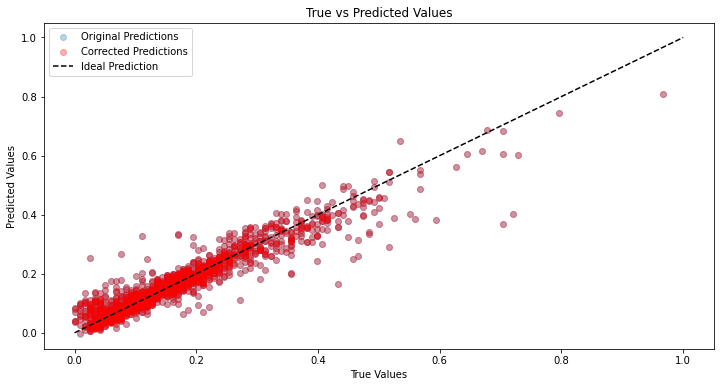

In [32]:
# Visualization
print("\n9. Generating visualizations...")
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.3, label='Original Predictions')
plt.scatter(y_test, y_pred_corrected, alpha=0.3, color='red', label='Corrected Predictions')
plt.plot([0, 1], [0, 1], '--k', label='Ideal Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values')
plt.legend()
plt.show()

In [33]:
# Feature Importance
print("\n10. Feature Importance:")
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(importance.head(10))


10. Feature Importance:
         Feature  Coefficient
2       C6H6(GT)     0.416834
4        NOx(GT)     0.314221
7   PT08.S4(NO2)     0.209279
0    PT08.S1(CO)     0.150987
1       NMHC(GT)     0.099548
8    PT08.S5(O3)    -0.098886
9              T    -0.091688
6        NO2(GT)     0.062535
10            RH    -0.048463
5   PT08.S3(NOx)     0.037515
